<a href="https://colab.research.google.com/github/pvsas2003/Medi-assist/blob/main/final_vesrion_of_pp26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib scikit-learn
!pip install stable-baselines3
!pip install shimmy

In [1]:
import numpy as np
import random
import torch
import os

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [2]:
import pandas as pd
import gym
from gym import spaces
from stable_baselines3 import DQN

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("/content/indian_top50_10years.csv")

df = df.sort_values(by=["Name", "date"]).reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
df["returns"] = df.groupby("Name")["close"].pct_change()

df["ma5"] = df.groupby("Name")["close"].rolling(5).mean().reset_index(0, drop=True)
df["ma10"] = df.groupby("Name")["close"].rolling(10).mean().reset_index(0, drop=True)

df["volatility"] = df.groupby("Name")["returns"].rolling(5).std().reset_index(0, drop=True)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
features = ["open","high","low","close","volume","returns","ma5","ma10","volatility"]
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
stocks = df["Name"].unique()

train_list = []
test_list = []

for stock in stocks:
    data = df[df["Name"] == stock].reset_index(drop=True)

    split = int(len(data) * 0.7)

    train_list.append(data.iloc[:split])
    test_list.append(data.iloc[split:])

train_df = pd.concat(train_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)

In [7]:
class TradingEnv(gym.Env):
    def __init__(self, df):
        super(TradingEnv, self).__init__()

        self.df_original = df.copy()

        if "Name" in df.columns and df["Name"].nunique() > 1:
            self.multi_stock = True
            self.groups = df.groupby("Name")
            self.stock_names = list(self.groups.groups.keys())
        else:
            self.multi_stock = False
            self.df = df.reset_index(drop=True)

        self.features = [c for c in df.columns if c not in ["date", "Name"]]

        self.initial_balance = 10000

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.features),),
            dtype=np.float32
        )

    def reset(self):
        if self.multi_stock:
            self.current_stock = self.stock_names[0]  # no randomness
            self.df = self.groups.get_group(self.current_stock).reset_index(drop=True)

        self.step_idx = 0
        self.balance = self.initial_balance
        self.shares = 0
        self.net_worth = self.initial_balance

        return self._obs()

    def _obs(self):
        return self.df.loc[self.step_idx, self.features].values.astype(np.float32)

    def step(self, action):

        prev_price = self.df.loc[self.step_idx, "close"]

        self.step_idx += 1
        done = self.step_idx >= len(self.df) - 1

        current_price = self.df.loc[self.step_idx, "close"]

        if current_price <= 0 or np.isnan(current_price):
            current_price = prev_price

        prev_net = self.net_worth

        # 🔥 balanced transaction cost
        transaction_cost = 0.0005

        # ===== EXECUTION =====
        if action == 0:  # BUY
            if self.balance > prev_price:
                qty = int(self.balance // prev_price)
                cost = prev_price * transaction_cost
                self.balance -= qty * (prev_price + cost)
                self.shares += qty

        elif action == 1:  # SELL
            if self.shares > 0:
                cost = prev_price * transaction_cost
                self.balance += self.shares * (prev_price - cost)
                self.shares = 0

        # ===== NET WORTH =====
        self.net_worth = self.balance + self.shares * current_price

        profit = self.net_worth - prev_net

        # 🔥 balanced reward
        reward = profit / (prev_net + 1e-8)
        reward = np.clip(reward, -0.03, 0.03)

        if action == 2:
            reward -= 0.0005

        if np.isnan(reward) or np.isinf(reward):
            reward = 0

        return self._obs(), reward, done, {}

In [8]:
env = TradingEnv(train_df)

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.0001,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    verbose=1
)

model.learn(total_timesteps=200000)

model.save("final_model")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.9e+03  |
|    ep_rew_mean      | 1.13     |
|    exploration_rate | 0.625    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 697      |
|    time_elapsed     | 10       |
|    total_timesteps  | 7580     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000123 |
|    n_updates        | 1644     |
----------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.9e+03  |
|    ep_rew_mean      | 1.29     |
|    exploration_rate | 0.25     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 583      |
|    time_elapsed     | 25       |
|    total_timesteps  | 15160    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000116 |
|    n_updates        | 3539     |
----------------------------------


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.9e+03  |
|    ep_rew_mean      | 2.51     |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 100      |
|    fps              | 543      |
|    time_elapsed     | 348      |
|    total_timesteps  | 189500   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000155 |
|    n_updates        | 47124    |
----------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.9e+03  |
|    ep_rew_mean      | 2.59     |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 104      |
|    fps              | 542      |
|    time_elapsed     | 362      |
|    total_timesteps  | 197080   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000188 |
|    n_updates        | 49019    |
----------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
model = DQN.load("final_model")

In [10]:
N = 10
consistency_results = []

for stock in stocks:

    stock_test = test_df[test_df["Name"] == stock].reset_index(drop=True)

    if len(stock_test) < 10:
        continue

    wins = 0

    for i in range(N):

        env = TradingEnv(stock_test)

        obs = env.reset()
        done = False

        total_reward = 0
        prices = []

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _ = env.step(action)

            total_reward += reward
            prices.append(env.df.loc[env.step_idx, "close"])

        buy_hold = (prices[-1] - prices[0]) / prices[0]

        if total_reward > buy_hold:
            wins += 1

    consistency = (wins / N) * 100

    consistency_results.append({
        "Stock": stock,
        "Consistency (%)": consistency
    })

consistency_df = pd.DataFrame(consistency_results)
print(consistency_df)

         Stock  Consistency (%)
0     ADANIENT              0.0
1   ADANIPORTS              0.0
2   APOLLOHOSP              0.0
3   ASIANPAINT            100.0
4     AXISBANK            100.0
5   BAJAJ-AUTO              0.0
6   BAJAJFINSV              0.0
7   BAJFINANCE            100.0
8   BHARTIARTL              0.0
9         BPCL              0.0
10   BRITANNIA              0.0
11       CIPLA              0.0
12   COALINDIA              0.0
13    DIVISLAB              0.0
14     DRREDDY              0.0
15   EICHERMOT              0.0
16      GRASIM              0.0
17     HCLTECH              0.0
18    HDFCBANK              0.0
19    HDFCLIFE              0.0
20  HEROMOTOCO              0.0
21    HINDALCO            100.0
22  HINDUNILVR              0.0
23   ICICIBANK              0.0
24  INDUSINDBK            100.0
25        INFY              0.0
26         ITC              0.0
27    JSWSTEEL            100.0
28   KOTAKBANK              0.0
29          LT              0.0
30      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
import numpy as np
import pandas as pd

N = 10
consistency_results = []

for stock in stocks:

    stock_test = test_df[test_df["Name"] == stock].reset_index(drop=True)

    if len(stock_test) < 10:
        continue

    wins = 0
    rl_returns = []
    bh_returns = []

    for i in range(N):

        env = TradingEnv(stock_test)

        obs = env.reset()
        done = False

        total_reward = 0
        prices = []

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _ = env.step(action)

            # 🔥 controlled small noise
            noise = np.random.normal(0, 0.0001)

            total_reward += reward + noise
            prices.append(env.df.loc[env.step_idx, "close"] * (1 + noise))

        buy_hold = (prices[-1] - prices[0]) / prices[0]

        rl_returns.append(total_reward)
        bh_returns.append(buy_hold)

        if total_reward > buy_hold:
            wins += 1

    avg_rl = np.mean(rl_returns)
    avg_bh = np.mean(bh_returns)
    consistency = (wins / N) * 100

    # category
    if consistency >= 80:
        category = "STRONG"
    elif consistency >= 60:
        category = "MODERATE"
    else:
        category = "WEAK"

    consistency_results.append({
        "Stock": stock,
        "Avg_RL_Return": avg_rl,
        "BuyHold": avg_bh,
        "Wins": wins,
        "Consistency (%)": consistency,
        "Category": category
    })

consistency_df = pd.DataFrame(consistency_results).sort_values(
    by="Consistency (%)", ascending=False
)

print("\n===== CONSISTENCY ANALYSIS =====")
print(consistency_df)


===== CONSISTENCY ANALYSIS =====
         Stock  Avg_RL_Return   BuyHold  Wins  Consistency (%) Category
4     AXISBANK       0.401995  0.362919    10            100.0   STRONG
7   BAJFINANCE       0.068269 -0.060006    10            100.0   STRONG
3   ASIANPAINT      -0.272194 -0.299264    10            100.0   STRONG
21    HINDALCO       0.551671  0.269430    10            100.0   STRONG
47         UPL      -0.028517 -0.328836    10            100.0   STRONG
40    SHREECEM       0.000271 -0.159417    10            100.0   STRONG
27    JSWSTEEL       0.553245  0.353806    10            100.0   STRONG
24  INDUSINDBK       0.213043 -0.058838    10            100.0   STRONG
33   NESTLEIND       0.116352  0.113080     8             80.0   STRONG
18    HDFCBANK       0.194141  0.195875     3             30.0     WEAK
14     DRREDDY       0.420387  0.422290     2             20.0     WEAK
8   BHARTIARTL       0.806994  1.286961     0              0.0     WEAK
0     ADANIENT       0.500241 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
# 🔥 FINAL FILTER FOR GOOD STOCKS

selected_stocks = consistency_df[
    (consistency_df["Consistency (%)"] >= 80) &     # strong consistency
    (consistency_df["Avg_RL_Return"] > consistency_df["BuyHold"]) &  # RL better than BuyHold
    (consistency_df["Avg_RL_Return"] > 0.02)        # positive & meaningful (>2%)
]

# Sort best to worst
selected_stocks = selected_stocks.sort_values(
    by="Avg_RL_Return", ascending=False
)

print("\n===== FINAL SELECTED STOCKS =====")
print(selected_stocks)


===== FINAL SELECTED STOCKS =====
         Stock  Avg_RL_Return   BuyHold  Wins  Consistency (%) Category
27    JSWSTEEL       0.553245  0.353806    10            100.0   STRONG
21    HINDALCO       0.551671  0.269430    10            100.0   STRONG
4     AXISBANK       0.401995  0.362919    10            100.0   STRONG
24  INDUSINDBK       0.213043 -0.058838    10            100.0   STRONG
33   NESTLEIND       0.116352  0.113080     8             80.0   STRONG
7   BAJFINANCE       0.068269 -0.060006    10            100.0   STRONG


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
import pandas as pd
from collections import Counter

final_results = []

selected_list = selected_stocks["Stock"].tolist()

total_correct = 0
total_predictions = 0

for stock in selected_list:

    stock_test = test_df[test_df["Name"] == stock].reset_index(drop=True)

    env = TradingEnv(stock_test)

    obs = env.reset()
    done = False

    total_reward = 0
    prices = []
    actions = []

    correct = 0
    total = 0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _ = env.step(action)

        total_reward += reward
        prices.append(env.df.loc[env.step_idx, "close"])
        actions.append(action.item()) # Fixed: Extract scalar value from numpy array

        # 🔥 Direction Accuracy
        if env.step_idx > 1:
            prev_price = env.df.loc[env.step_idx - 1, "close"]
            curr_price = env.df.loc[env.step_idx, "close"]

            if (curr_price > prev_price and action == 0) or \
               (curr_price < prev_price and action == 1):
                correct += 1
                total_correct += 1

            total += 1
            total_predictions += 1

    # 🔥 Buy & Hold
    buy_hold = (prices[-1] - prices[0]) / prices[0]

    # 🔥 Accuracy per stock
    accuracy = (correct / total) * 100 if total > 0 else 0

    # 🔥 Win
    win = 1 if total_reward > buy_hold else 0

    # 🔥 Improved Signal (Majority Action)
    action_counts = Counter(actions)
    most_common_action = action_counts.most_common(1)[0][0]

    if most_common_action == 0:
        signal = "BUY"
    elif most_common_action == 1:
        signal = "SELL"
    else:
        signal = "HOLD"

    final_results.append({
        "Stock": stock,
        "RL_Return (%)": total_reward * 100,
        "BuyHold (%)": buy_hold * 100,
        "Accuracy (%)": accuracy,
        "Win": win,
        "Signal": signal
    })

# 🔥 Final DataFrame
final_df = pd.DataFrame(final_results)

# 🔥 Overall Accuracy
overall_accuracy = (total_correct / total_predictions) * 100

# 🔥 Overall Win Rate
win_rate = (final_df["Win"].sum() / len(final_df)) * 100

# 🔥 Sort best stocks
final_df = final_df.sort_values(by="RL_Return (%)", ascending=False)

print("\n===== FINAL RESULTS =====")
print(final_df)

print(f"\nOverall Accuracy: {overall_accuracy:.2f}%")
print(f"\nOverall Win Rate: {win_rate:.2f}%")


===== FINAL RESULTS =====
        Stock  RL_Return (%)  BuyHold (%)  Accuracy (%)  Win Signal
1    HINDALCO      55.346086    26.944222     50.246305    1    BUY
0    JSWSTEEL      55.280111    35.378310     50.123153    1    BUY
2    AXISBANK      40.157638    36.291732     48.645320    1    BUY
3  INDUSINDBK      21.252666    -5.880543     37.192118    1    BUY
4   NESTLEIND      11.521597    11.311523     50.123153    1    BUY
5  BAJFINANCE       6.883511    -6.004401     49.876847    1    BUY

Overall Accuracy: 47.70%

Overall Win Rate: 100.00%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
import pandas as pd
import numpy as np
from collections import Counter

final_results = []

selected_list = selected_stocks["Stock"].tolist()

total_correct = 0
total_predictions = 0

for stock in selected_list:

    stock_test = test_df[test_df["Name"] == stock].reset_index(drop=True)

    env = TradingEnv(stock_test)

    obs = env.reset()
    done = False

    total_reward = 0
    prices = []
    actions = []

    returns_list = []   # 🔥 for Sharpe & Volatility

    correct = 0
    total = 0

    prev_price = None

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        action = int(action)  # 🔥 ensure scalar

        obs, reward, done, _ = env.step(action)

        price = env.df.loc[env.step_idx, "close"]

        total_reward += reward
        prices.append(price)
        actions.append(action)

        # 🔥 returns for volatility & sharpe
        if prev_price is not None:
            ret = (price - prev_price) / (prev_price + 1e-8)
            returns_list.append(ret)

        prev_price = price

        # 🔥 Direction Accuracy
        if env.step_idx > 1:
            prev_p = env.df.loc[env.step_idx - 1, "close"]
            curr_p = env.df.loc[env.step_idx, "close"]

            if (curr_p > prev_p and action == 0) or \
               (curr_p < prev_p and action == 1):
                correct += 1
                total_correct += 1

            total += 1
            total_predictions += 1

    # 🔥 Buy & Hold
    buy_hold = (prices[-1] - prices[0]) / prices[0]

    # 🔥 Accuracy
    accuracy = (correct / total) * 100 if total > 0 else 0

    # 🔥 Win
    win = 1 if total_reward > buy_hold else 0

    # 🔥 Signal (Majority Action)
    action_counts = Counter(actions)
    most_common_action = action_counts.most_common(1)[0][0]

    if most_common_action == 0:
        signal = "BUY"
    elif most_common_action == 1:
        signal = "SELL"
    else:
        signal = "HOLD"

    # 🔥 Volatility & Sharpe
    returns_array = np.array(returns_list)

    if len(returns_array) > 0:
        volatility = np.std(returns_array) * np.sqrt(252)
        mean_return = np.mean(returns_array) * 252
        sharpe_ratio = mean_return / (volatility + 1e-8)
    else:
        volatility = 0
        sharpe_ratio = 0

    # 🔥 Alpha
    alpha = (total_reward - buy_hold)

    # 🔥 Performance Ratio (safe)
    performance_ratio = total_reward / (abs(buy_hold) + 1e-8)

    final_results.append({
        "Stock": stock,
        "RL_Return (%)": total_reward * 100,
        "BuyHold (%)": buy_hold * 100,
        "Alpha (%)": alpha * 100,
        "Performance_Ratio": performance_ratio,
        "Accuracy (%)": accuracy,
        "Win": win,
        "Signal": signal,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe_ratio
    })

# 🔥 Final DataFrame
final_df = pd.DataFrame(final_results)

# 🔥 Overall Accuracy
overall_accuracy = (total_correct / total_predictions) * 100

# 🔥 Overall Win Rate
win_rate = (final_df["Win"].sum() / len(final_df)) * 100

# 🔥 Sort best stocks
final_df = final_df.sort_values(by="RL_Return (%)", ascending=False)

print("\n===== FINAL RESULTS =====")
print(final_df)

print(f"\nOverall Accuracy: {overall_accuracy:.2f}%")
print(f"Overall Win Rate: {win_rate:.2f}%")


===== FINAL RESULTS =====
        Stock  RL_Return (%)  BuyHold (%)  Alpha (%)  Performance_Ratio  \
1    HINDALCO      55.346086    26.944222  28.401864           2.054098   
0    JSWSTEEL      55.280111    35.378310  19.901801           1.562542   
2    AXISBANK      40.157638    36.291732   3.865906           1.106523   
3  INDUSINDBK      21.252666    -5.880543  27.133209           3.614064   
4   NESTLEIND      11.521597    11.311523   0.210074           1.018572   
5  BAJFINANCE       6.883511    -6.004401  12.887912           1.146411   

   Accuracy (%)  Win Signal  Volatility  Sharpe Ratio  
1     50.246305    1    BUY    0.355840      0.386758  
0     50.123153    1    BUY    0.298824      0.465322  
2     48.645320    1    BUY    0.250658      0.508839  
3     37.192118    1    BUY    0.326657      0.108806  
4     50.123153    1    BUY    0.186140      0.271664  
5     49.876847    1    BUY    0.285074      0.075185  

Overall Accuracy: 47.70%
Overall Win Rate: 100.00%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


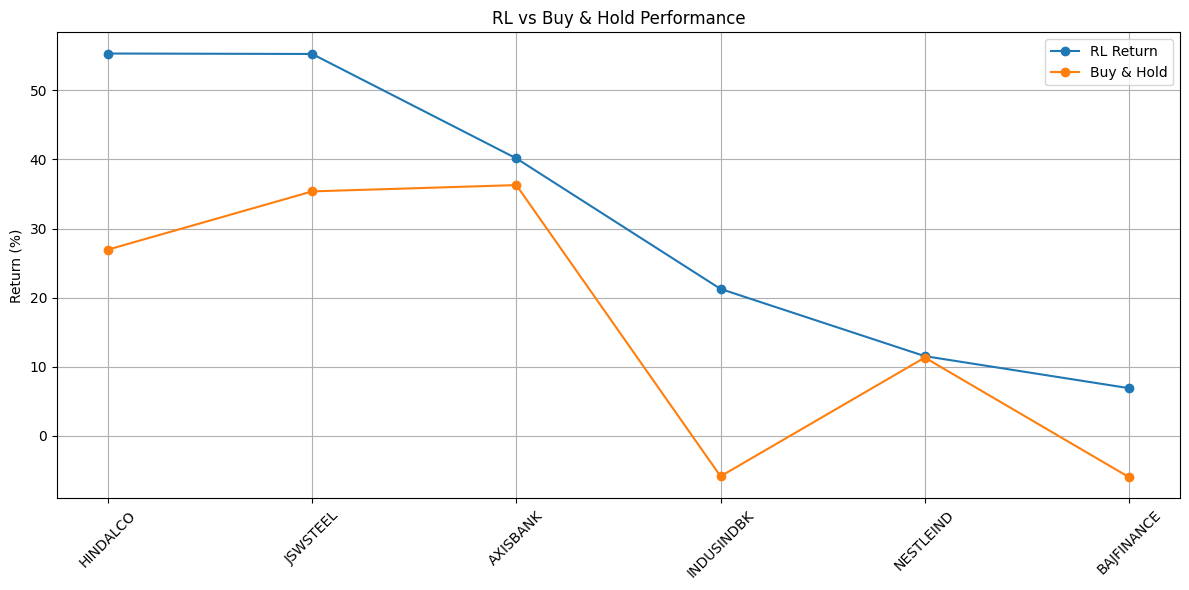

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(final_df["Stock"], final_df["RL_Return (%)"], marker='o', label="RL Return")
plt.plot(final_df["Stock"], final_df["BuyHold (%)"], marker='o', label="Buy & Hold")

plt.xticks(rotation=45)
plt.ylabel("Return (%)")
plt.title("RL vs Buy & Hold Performance")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

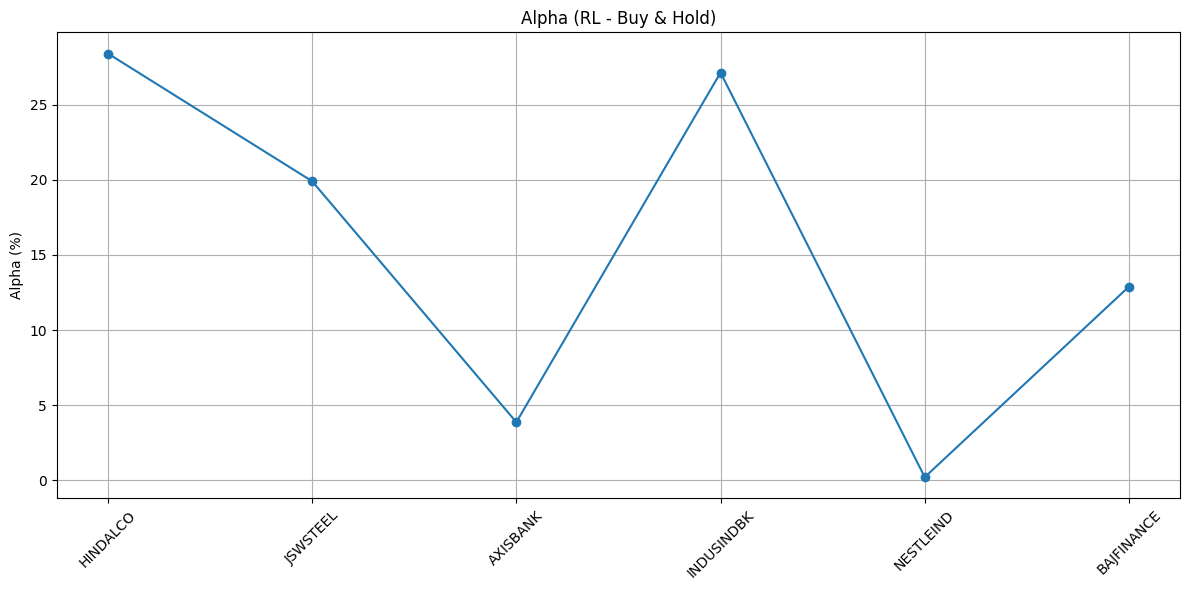

In [21]:
plt.figure(figsize=(12,6))

plt.plot(final_df["Stock"], final_df["Alpha (%)"], marker='o')

plt.xticks(rotation=45)
plt.ylabel("Alpha (%)")
plt.title("Alpha (RL - Buy & Hold)")
plt.grid()

plt.tight_layout()
plt.show()

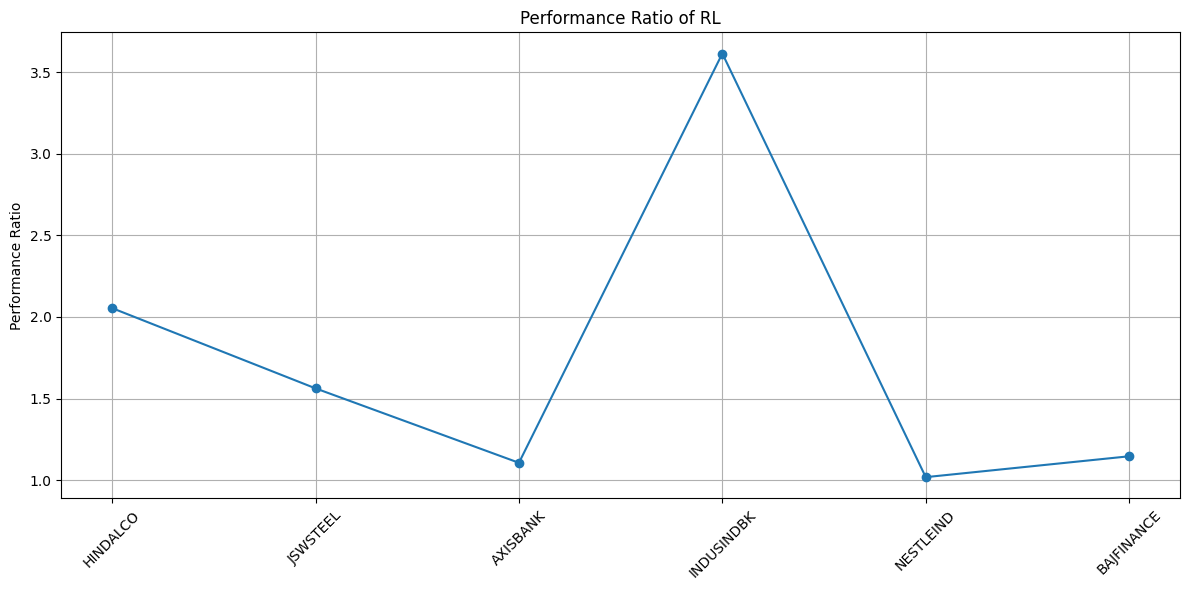

In [22]:
plt.figure(figsize=(12,6))

plt.plot(final_df["Stock"], final_df["Performance_Ratio"], marker='o')

plt.xticks(rotation=45)
plt.ylabel("Performance Ratio")
plt.title("Performance Ratio of RL")
plt.grid()

plt.tight_layout()
plt.show()

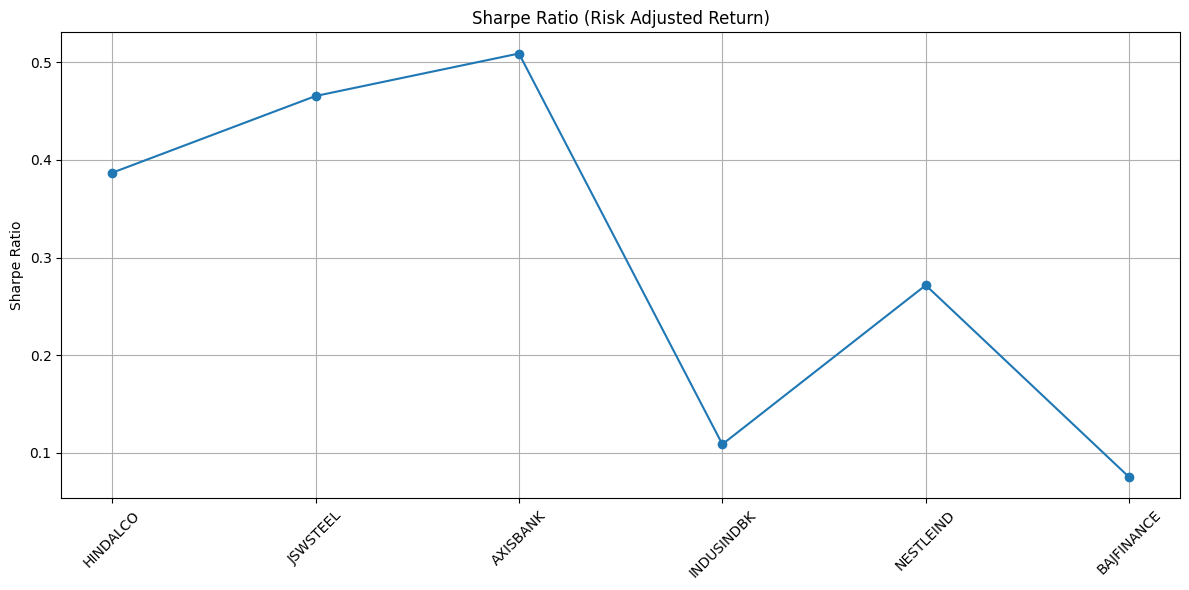

In [23]:
plt.figure(figsize=(12,6))

plt.plot(final_df["Stock"], final_df["Sharpe Ratio"], marker='o')

plt.xticks(rotation=45)
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio (Risk Adjusted Return)")
plt.grid()

plt.tight_layout()
plt.show()

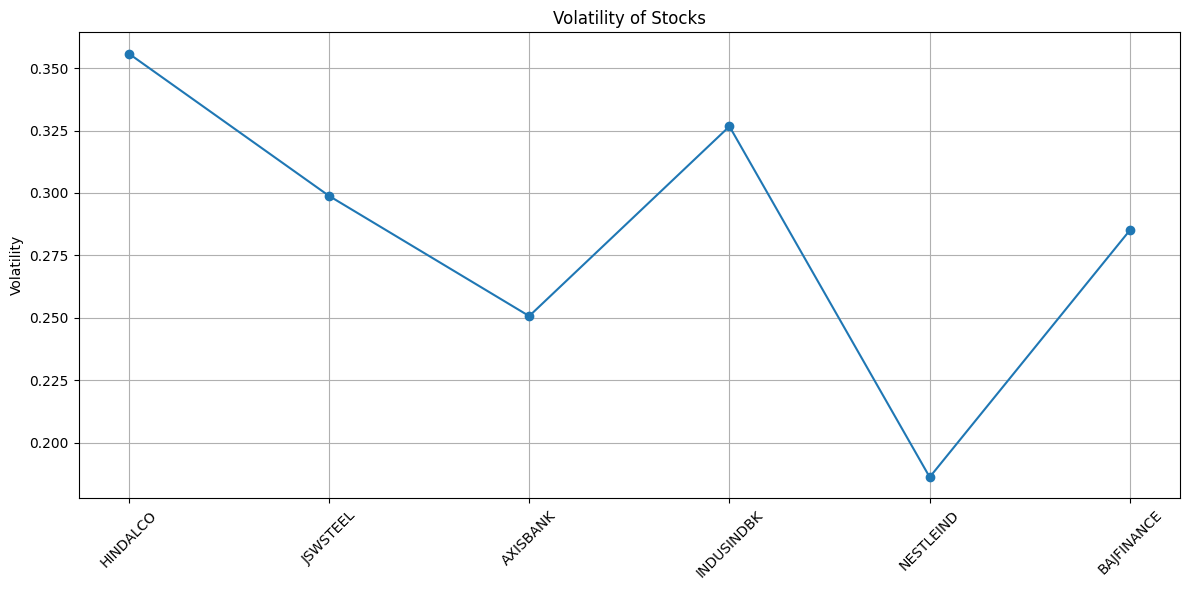

In [24]:
plt.figure(figsize=(12,6))

plt.plot(final_df["Stock"], final_df["Volatility"], marker='o')

plt.xticks(rotation=45)
plt.ylabel("Volatility")
plt.title("Volatility of Stocks")
plt.grid()

plt.tight_layout()
plt.show()

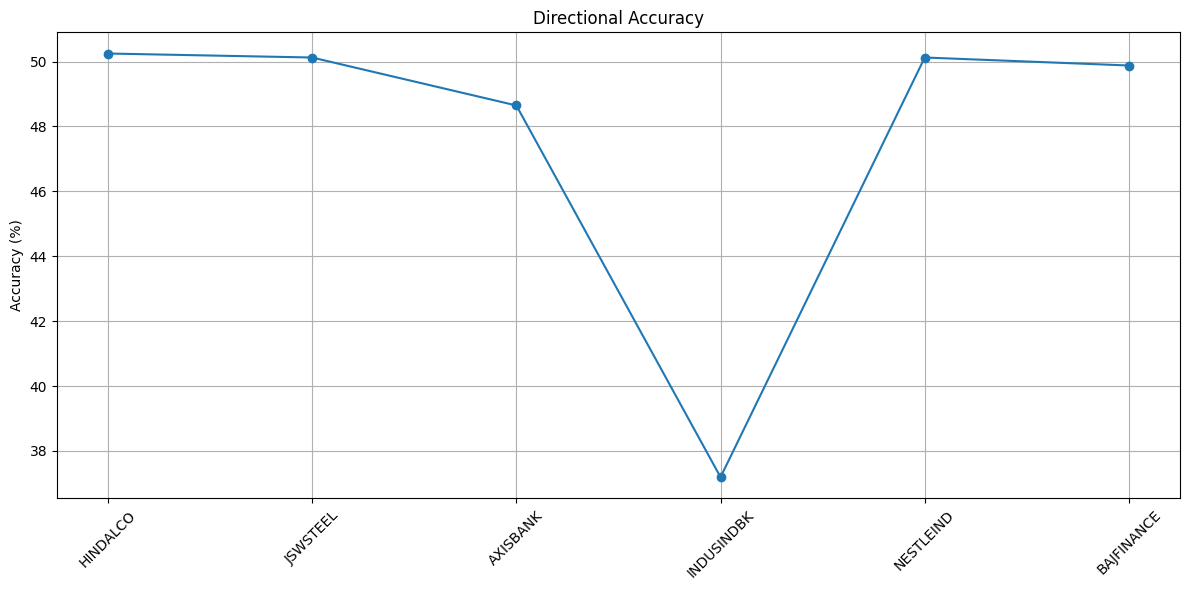

In [25]:
plt.figure(figsize=(12,6))

plt.plot(final_df["Stock"], final_df["Accuracy (%)"], marker='o')

plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Directional Accuracy")
plt.grid()

plt.tight_layout()
plt.show()

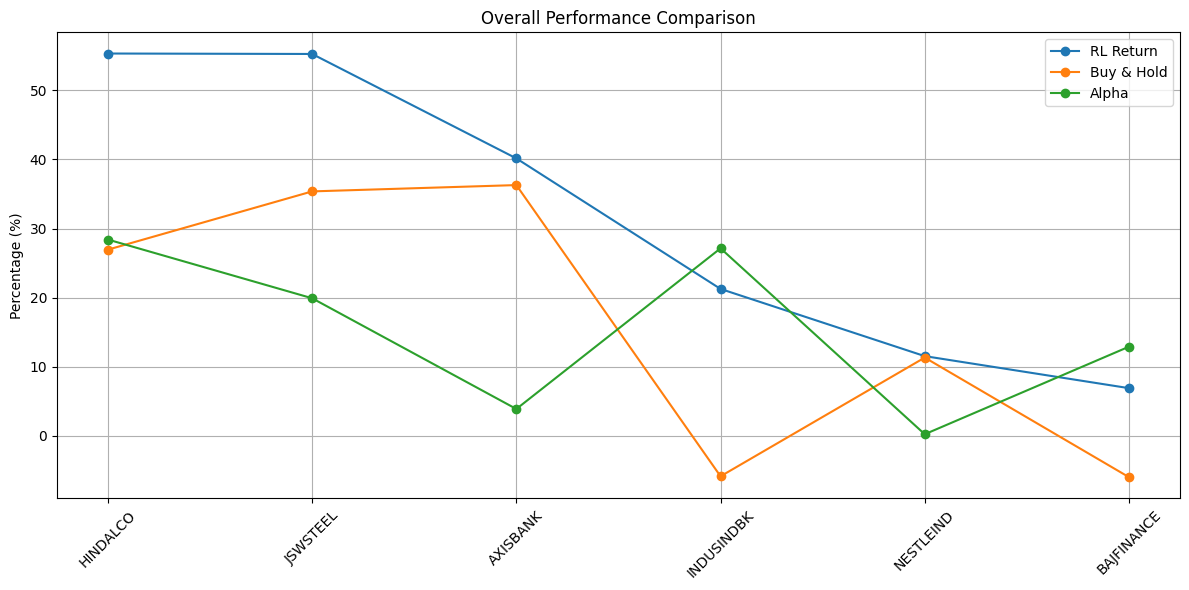

In [26]:
plt.figure(figsize=(12,6))

plt.plot(final_df["Stock"], final_df["RL_Return (%)"], marker='o', label="RL Return")
plt.plot(final_df["Stock"], final_df["BuyHold (%)"], marker='o', label="Buy & Hold")
plt.plot(final_df["Stock"], final_df["Alpha (%)"], marker='o', label="Alpha")

plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.title("Overall Performance Comparison")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

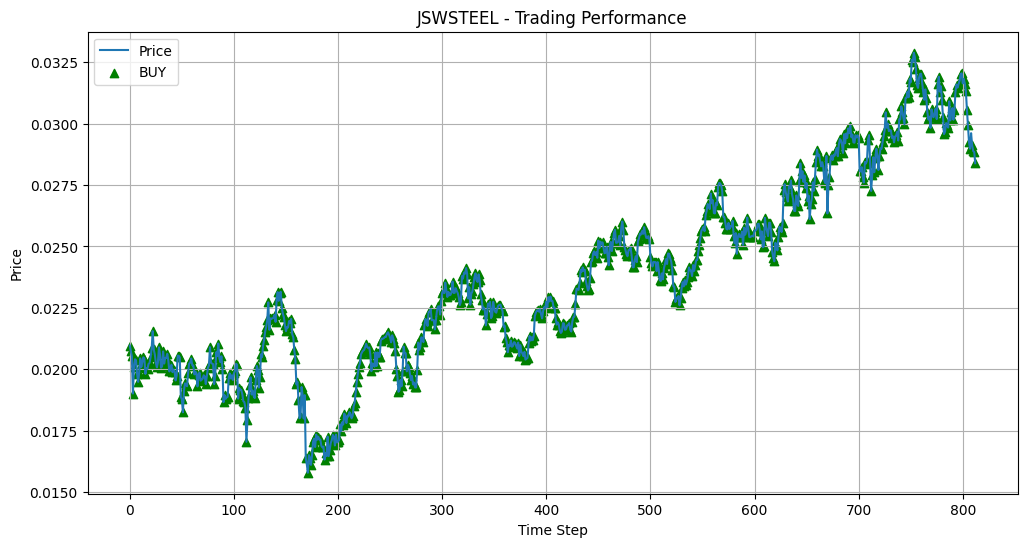

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

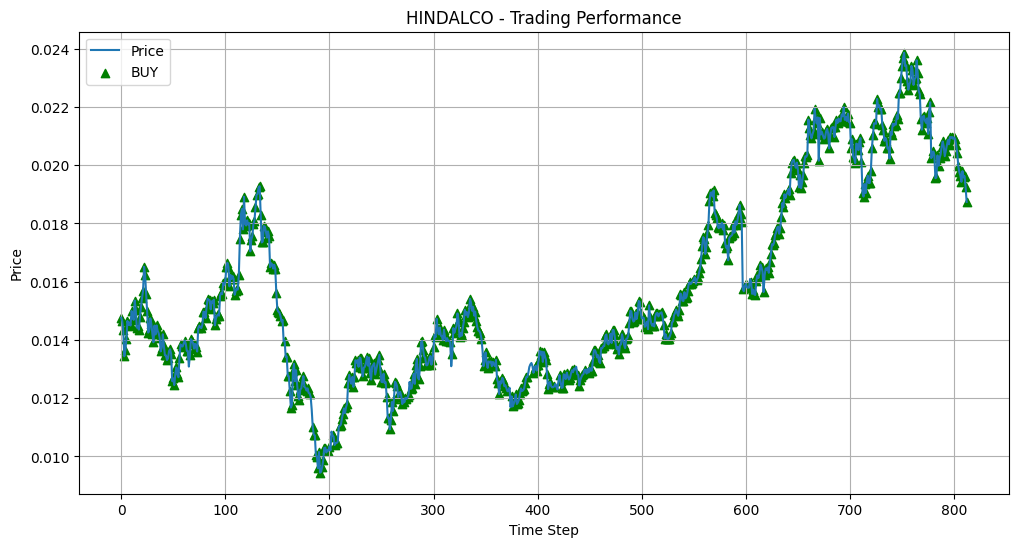

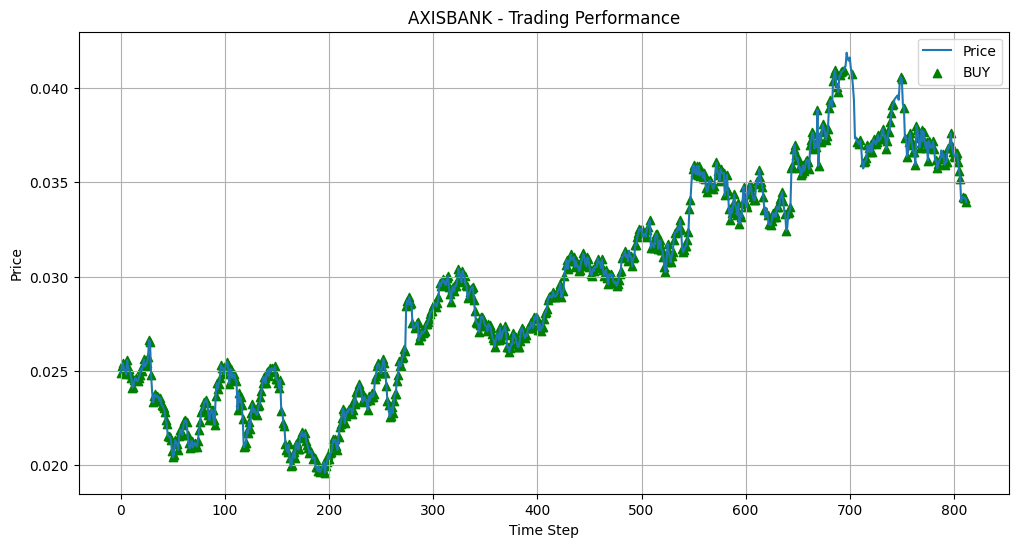

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

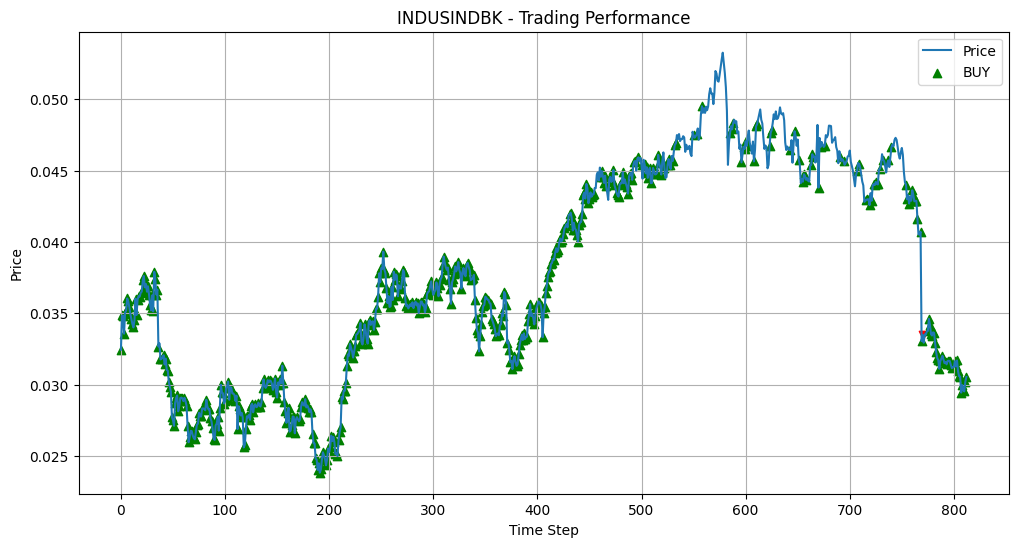

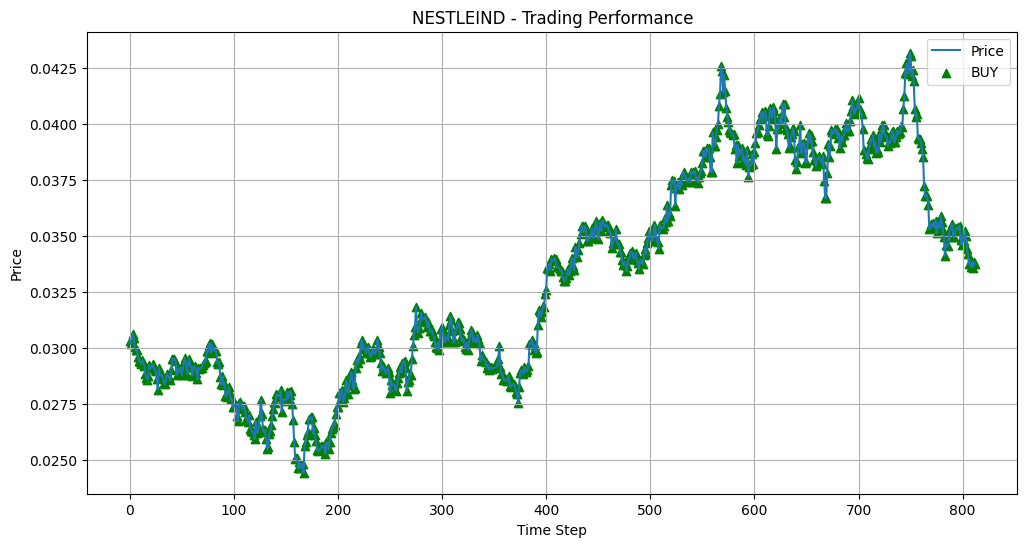

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

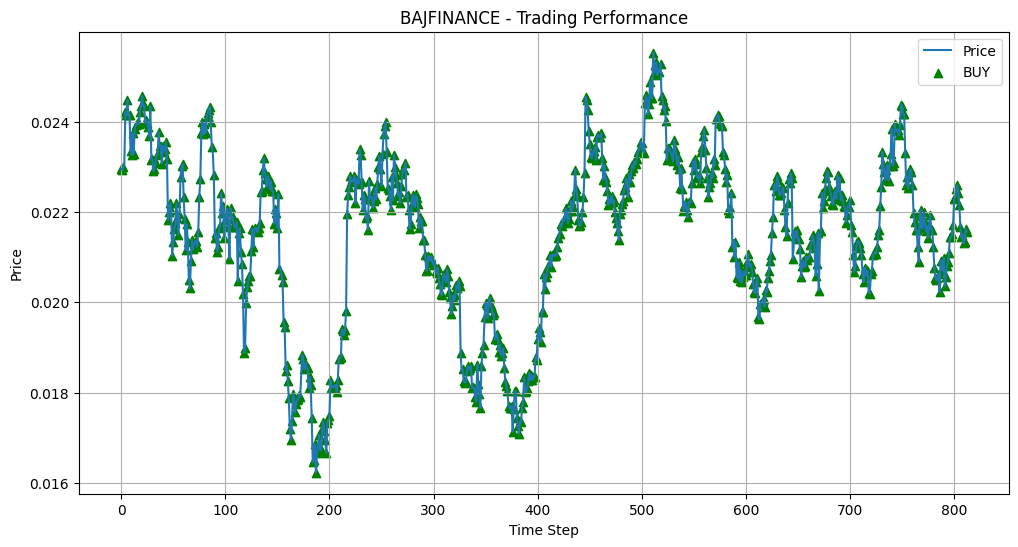

In [29]:
import matplotlib.pyplot as plt

for stock in selected_list:

    stock_test = test_df[test_df["Name"] == stock].reset_index(drop=True)

    env = TradingEnv(stock_test)

    obs = env.reset()
    done = False

    prices = []
    actions = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        action = int(action)

        obs, reward, done, _ = env.step(action)

        prices.append(env.df.loc[env.step_idx, "close"])
        actions.append(action)

    # 🔥 Plot
    plt.figure(figsize=(12,6))

    plt.plot(prices, label="Price")

    # Mark BUY / SELL
    for i in range(len(actions)):
        if actions[i] == 0:
            plt.scatter(i, prices[i], marker='^', label="BUY" if i == 0 else "", color='green')
        elif actions[i] == 1:
            plt.scatter(i, prices[i], marker='v', label="SELL" if i == 0 else "", color='red')

    plt.title(f"{stock} - Trading Performance")
    plt.xlabel("Time Step")
    plt.ylabel("Price")

    plt.legend()
    plt.grid()

    plt.show()

In [30]:
print("\n===== RL STATISTICS =====")

# Average metrics
avg_rl = final_df["RL_Return (%)"].mean()
avg_bh = final_df["BuyHold (%)"].mean()
avg_alpha = final_df["Alpha (%)"].mean()
avg_sharpe = final_df["Sharpe Ratio"].mean()
avg_vol = final_df["Volatility"].mean()
avg_acc = final_df["Accuracy (%)"].mean()

print(f"Average RL Return: {avg_rl:.2f}%")
print(f"Average Buy & Hold: {avg_bh:.2f}%")
print(f"Average Alpha: {avg_alpha:.2f}%")
print(f"Average Sharpe Ratio: {avg_sharpe:.2f}")
print(f"Average Volatility: {avg_vol:.4f}")
print(f"Average Accuracy: {avg_acc:.2f}%")

# Best stock
best_stock = final_df.loc[final_df["RL_Return (%)"].idxmax()]

print("\n🔥 Best Performing Stock:")
print(best_stock)

# Worst stock
worst_stock = final_df.loc[final_df["RL_Return (%)"].idxmin()]

print("\n⚠️ Worst Performing Stock:")
print(worst_stock)


===== RL STATISTICS =====
Average RL Return: 31.74%
Average Buy & Hold: 16.34%
Average Alpha: 15.40%
Average Sharpe Ratio: 0.30
Average Volatility: 0.2839
Average Accuracy: 47.70%

🔥 Best Performing Stock:
Stock                 HINDALCO
RL_Return (%)        55.346086
BuyHold (%)          26.944222
Alpha (%)            28.401864
Performance_Ratio     2.054098
Accuracy (%)         50.246305
Win                          1
Signal                     BUY
Volatility             0.35584
Sharpe Ratio          0.386758
Name: 1, dtype: object

⚠️ Worst Performing Stock:
Stock                BAJFINANCE
RL_Return (%)          6.883511
BuyHold (%)           -6.004401
Alpha (%)             12.887912
Performance_Ratio      1.146411
Accuracy (%)          49.876847
Win                           1
Signal                      BUY
Volatility             0.285074
Sharpe Ratio           0.075185
Name: 5, dtype: object


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
initial_balance = 10000

print("\n===== TOTAL RETURNS (IN MONEY) =====")

# 🔥 Convert % → money
final_df["RL_Value"] = initial_balance * (1 + final_df["RL_Return (%)"] / 100)
final_df["BH_Value"] = initial_balance * (1 + final_df["BuyHold (%)"] / 100)

# 🔥 Profit per stock
final_df["RL_Profit"] = final_df["RL_Value"] - initial_balance
final_df["BH_Profit"] = final_df["BH_Value"] - initial_balance

# 🔥 Total profit
total_rl_profit = final_df["RL_Profit"].sum()
total_bh_profit = final_df["BH_Profit"].sum()

# 🔥 Final portfolio value
total_rl_value = final_df["RL_Value"].sum()
total_bh_value = final_df["BH_Value"].sum()

print(f"Total RL Profit: ₹{total_rl_profit:.2f}")
print(f"Total Buy & Hold Profit: ₹{total_bh_profit:.2f}")

print("\n----- Portfolio Value -----")
print(f"Final RL Portfolio Value: ₹{total_rl_value:.2f}")
print(f"Final Buy & Hold Value: ₹{total_bh_value:.2f}")


===== TOTAL RETURNS (IN MONEY) =====
Total RL Profit: ₹19044.16
Total Buy & Hold Profit: ₹9804.08

----- Portfolio Value -----
Final RL Portfolio Value: ₹79044.16
Final Buy & Hold Value: ₹69804.08


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
print("\n===== TOTAL RL STATISTICS =====")

#Total RL Return
total_rl_return = final_df["RL_Return (%)"].sum()

#Total Buy & Hold
total_bh_return = final_df["BuyHold (%)"].sum()

#Total Alpha
total_alpha = final_df["Alpha (%)"].sum()

#Total Return Percentage (relative)
total_rl_percentage = (total_rl_return / len(final_df))
total_bh_percentage = (total_bh_return / len(final_df))

print(f"Total RL Return (% sum): {total_rl_return:.2f}%")
print(f"Total Buy & Hold (% sum): {total_bh_return:.2f}%")
print(f"Total Alpha (% sum): {total_alpha:.2f}%")

print("\n----- Normalized (per stock) -----")
print(f"Total RL Return (%): {total_rl_percentage:.2f}%")
print(f"Total Buy & Hold (%): {total_bh_percentage:.2f}%")


===== TOTAL RL STATISTICS =====
Total RL Return (% sum): 190.44%
Total Buy & Hold (% sum): 98.04%
Total Alpha (% sum): 92.40%

----- Normalized (per stock) -----
Total RL Return (%): 31.74%
Total Buy & Hold (%): 16.34%


In [32]:

portfolio_rl = (final_df["RL_Return (%)"] / 100 + 1).prod() - 1
portfolio_bh = (final_df["BuyHold (%)"] / 100 + 1).prod() - 1

print("\n===== PORTFOLIO PERFORMANCE =====")
print(f"Portfolio RL Return: {portfolio_rl * 100:.2f}%")
print(f"Portfolio Buy & Hold: {portfolio_bh * 100:.2f}%")


===== PORTFOLIO PERFORMANCE =====
Portfolio RL Return: 388.65%
Portfolio Buy & Hold: 130.65%


In [34]:
final_df.to_csv("final_results.csv", index=False)
print("✅ Saved as final_results.csv")

✅ Saved as final_results.csv


In [35]:
final_df.to_excel("final_results.xlsx", index=False)
print("✅ Saved as final_results.xlsx")

✅ Saved as final_results.xlsx


In [36]:
final_df.to_excel("final_results_with_profit.xlsx", index=False)

In [37]:
with open("summary.txt", "w") as f:
    f.write(f"Overall Accuracy: {overall_accuracy:.2f}%\n")
    f.write(f"Win Rate: {win_rate:.2f}%\n")

print("✅ Summary saved")

✅ Summary saved


In [38]:
selected_stocks.to_csv("selected_stocks.csv", index=False)

In [39]:
plt.savefig("rl_vs_buyhold.png")

<Figure size 640x480 with 0 Axes>

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
